In [22]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ee
import geemap
import xesmf as xe

## Default Model Grid  
1x1

In [7]:
# Create a regional regular latitude longitude grid of 1 degree resolution
#  xe.util.cf_grid_2d(lon0_b, lon1_b, d_lon, lat0_b, lat1_b, d_lat)
target_grid = xe.util.cf_grid_2d(0, 360, 1, -90, 90, 1)
target_grid.to_netcdf("maskdata/prof/gchi_targetgrid_1x1_global_20260326.nc")

## NDVI  
MODIS NDVI (2010-2014)

In [9]:
# GCHI global 1x1 model grid
target_grid = xr.open_dataset("maskdata/prod/gchi_targetgrid_1x1_global_20260326.nc")

In [16]:
ee.Authenticate()
ee.Initialize(project="ee-maxwellelling")

collection = (
    ee.ImageCollection("MODIS/MOD09GA_006_NDVI")
    .filterDate("2010-01-01", "2014-12-31")
    .filterBounds(ee.Geometry.BBox(-180, -90, 180, 90))
)

ds = geemap.ee_to_xarray(collection,  crs="EPSG:4326")
ds = ds.chunk({"time": -1, "lat": "auto", "lon": "auto"})
ds_mon = ds.resample(time="ME").mean().compute()

# use 2010-2014 NDVI climatology
ds_clim = ds_mon.groupby("time.month").mean()

In [19]:
# regrid to 1x1 default GCHI grid
def regrid(ds_in, regrid_to, method='bilinear'):
    regridder = xe.Regridder(ds_in, regrid_to, method=method, periodic=True, ignore_degenerate=True)
    ds_out = regridder(ds_in)
    return ds_out
    
ds_clim_rg = regrid(ds_clim, target_grid, method='bilinear') # regrid to 1x1

/opt/homebrew/Caskroom/miniconda/base/envs/kitchensink/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


In [20]:
# VBD suitability mask = at least two consecutive months of NDVI above 0.125 (Ryan et al 2015; https://doi.org/10.1089/vbz.2015.1822)
green_areas = (ds_clim_rg["NDVI"] > 0.125).rolling(month=2).sum().max(dim="month") >= 2

Greater than 0.125 NDVI for at least two months (MODIS 2010-2014 climatology)


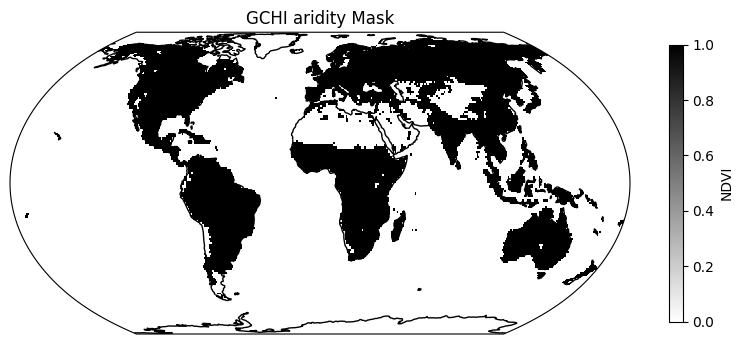

In [35]:
# mask plotted
fig,ax=plt.subplots(1,1,subplot_kw={'projection':ccrs.EqualEarth()}, figsize=(10, 6))
green_areas.plot(transform=ccrs.PlateCarree(), cmap="binary", cbar_kwargs={"shrink":0.6})
plt.title("GCHI aridity Mask")
ax.coastlines();
print("Greater than 0.125 NDVI for at least two months (MODIS 2010-2014 climatology)")

In [38]:
green_areas = green_areas.rename("aridity_mask").to_dataset()
green_areas.aridity_mask.attrs["units"] = "boolean"
green_areas.attrs["description"] = "Aridity mask based on 2010-2014 MODIS NDVI climatology. True if > than 0.125 NDVI for at least two months"
green_areas.attrs["cell_operations"] = "NDVI regridded to 1x1 degree grid (bilinear interpolation)"
green_areas.to_netcdf("maskdata/prod/gchi_aridity_mask_1x1_20260326.nc")